In [55]:
import json
import os
import time
import requests
import pandas as pd
from neo4j import GraphDatabase
import chromadb
from chromadb.utils import embedding_functions
from tabulate import tabulate
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "hotpot_dev_distractor_v1.json"   
CHROMA_PATH = "hotpot_chroma_db"

NEO4J_URI = "bolt://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "passpass"

MODEL_URL = "http://localhost:11434"
MODEL_ID = "qwen2.5:7b"

In [ ]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

dataset = load_json(DATA_PATH)
print("Loaded", len(dataset), "questions")

Loaded 7405 questions


In [4]:
sample = dataset[0]

print("ID:", sample["id"])
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Type:", sample["type"])
print("Level:", sample["level"])
print("Supporting facts:", sample["supporting_facts"])
print("Context titles:", sample["context"]["title"])

ID: 5a8b57f25542995d1e6f1371
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Answer: yes
Type: comparison
Level: hard
Supporting facts: {'title': ['Scott Derrickson', 'Ed Wood'], 'sent_id': [0, 0]}
Context titles: ['Ed Wood (film)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)']


In [5]:
def flatten_hotpot(dataset):
    docs = []

    for item in dataset:
        qid = item["id"]
        question = item["question"]
        answer = item["answer"]
        qtype = item.get("type")
        level = item.get("level")

        support_pairs = set(
            zip(
                item["supporting_facts"]["title"],
                item["supporting_facts"]["sent_id"]
            )
        )

        titles = item["context"]["title"]
        sentence_groups = item["context"]["sentences"]

        for title, sentences in zip(titles, sentence_groups):
            paragraph = " ".join(sentences)

            supporting_sentence_texts = [
                sent
                for idx, sent in enumerate(sentences)
                if (title, idx) in support_pairs
            ]

            docs.append({
                "qid": qid,
                "question": question,
                "answer": answer,
                "type": qtype,
                "level": level,
                "title": title,
                "paragraph": paragraph,
                "sentences": sentences,
                "supporting_sentences": supporting_sentence_texts,
                "is_support_page": title in item["supporting_facts"]["title"]
            })

    return docs

docs = flatten_hotpot(dataset)
print("Flattened docs:", len(docs))


Flattened docs: 73700


In [6]:
client = chromadb.PersistentClient(path=CHROMA_PATH)

ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

collection = client.get_or_create_collection(
    name="hotpot_pages",
    embedding_function=ef
)


c:\Users\omarl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7350.92it/s]


In [8]:
import re

BATCH_SIZE = 500

ids = []
texts = []
metadatas = []

for i, d in enumerate(docs):
    safe_title = re.sub(r"[^a-zA-Z0-9_-]", "_", d['title'])
    doc_id = f"{d['qid']}_{i}_{safe_title}"[:512]

    text = f"""Title: {d['title']}
Question: {d['question']}
Paragraph: {d['paragraph']}""".strip()

    ids.append(doc_id)
    texts.append(text)
    metadatas.append({
        "qid": d["qid"],
        "title": d["title"],
        "answer": d["answer"],
        "type": d["type"],
        "level": d["level"],
        "is_support_page": str(d["is_support_page"])
    })

for start in range(0, len(ids), BATCH_SIZE):
    end = start + BATCH_SIZE
    collection.upsert(
        ids=ids[start:end],
        documents=texts[start:end],
        metadatas=metadatas[start:end]
    )
    print(f"Upserted {min(end, len(ids))}/{len(ids)}")

print("Chroma count:", collection.count())

Upserted 500/73700
Upserted 1000/73700
Upserted 1500/73700
Upserted 2000/73700
Upserted 2500/73700
Upserted 3000/73700
Upserted 3500/73700
Upserted 4000/73700
Upserted 4500/73700
Upserted 5000/73700
Upserted 5500/73700
Upserted 6000/73700
Upserted 6500/73700
Upserted 7000/73700
Upserted 7500/73700
Upserted 8000/73700
Upserted 8500/73700
Upserted 9000/73700
Upserted 9500/73700
Upserted 10000/73700
Upserted 10500/73700
Upserted 11000/73700
Upserted 11500/73700
Upserted 12000/73700
Upserted 12500/73700
Upserted 13000/73700
Upserted 13500/73700
Upserted 14000/73700
Upserted 14500/73700
Upserted 15000/73700
Upserted 15500/73700
Upserted 16000/73700
Upserted 16500/73700
Upserted 17000/73700
Upserted 17500/73700
Upserted 18000/73700
Upserted 18500/73700
Upserted 19000/73700
Upserted 19500/73700
Upserted 20000/73700
Upserted 20500/73700
Upserted 21000/73700
Upserted 21500/73700
Upserted 22000/73700
Upserted 22500/73700
Upserted 23000/73700
Upserted 23500/73700
Upserted 24000/73700
Upserted 245

In [9]:
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)

def run_cypher(query, params=None):
    params = params or {}
    with driver.session() as session:
        result = session.run(query, params)
        return [record.data() for record in result]


In [14]:
run_cypher("MATCH (n) DETACH DELETE n")
print("Neo4j cleared")


Neo4j cleared


In [15]:
constraints = [
    "CREATE CONSTRAINT question_id IF NOT EXISTS FOR (q:Question) REQUIRE q.id IS UNIQUE",
    "CREATE CONSTRAINT page_title IF NOT EXISTS FOR (p:Page) REQUIRE p.title IS UNIQUE",
    "CREATE CONSTRAINT answer_text IF NOT EXISTS FOR (a:Answer) REQUIRE a.text IS UNIQUE",
    "CREATE CONSTRAINT sentence_id IF NOT EXISTS FOR (s:Sentence) REQUIRE s.id IS UNIQUE"
]

for c in constraints:
    run_cypher(c)

print("Constraints created")


Constraints created


In [16]:
def insert_hotpot_item(tx, item):
    qid = item["id"]
    question = item["question"]
    answer = item["answer"]
    qtype = item.get("type")
    level = item.get("level")

    tx.run("""
        MERGE (q:Question {id:$qid})
        SET q.text = $question,
            q.answer = $answer,
            q.type = $qtype,
            q.level = $level
        MERGE (a:Answer {text:$answer})
        MERGE (q)-[:HAS_ANSWER]->(a)
    """, qid=qid, question=question, answer=answer, qtype=qtype, level=level)

    support_pairs = set(
        zip(
            item["supporting_facts"]["title"],
            item["supporting_facts"]["sent_id"]
        )
    )

    titles = item["context"]["title"]
    sentence_groups = item["context"]["sentences"]

    for title, sentences in zip(titles, sentence_groups):
        tx.run("""
            MATCH (q:Question {id:$qid})
            MERGE (p:Page {title:$title})
            MERGE (q)-[:HAS_CONTEXT]->(p)
        """, qid=qid, title=title)

        if title in item["supporting_facts"]["title"]:
            tx.run("""
                MATCH (q:Question {id:$qid})
                MATCH (p:Page {title:$title})
                MERGE (q)-[:SUPPORT_PAGE]->(p)
            """, qid=qid, title=title)

        for sent_id, sent_text in enumerate(sentences):
            sid = f"{qid}::{title}::{sent_id}"

            tx.run("""
                MATCH (p:Page {title:$title})
                MERGE (s:Sentence {id:$sid})
                SET s.text = $text,
                    s.sent_id = $sent_id,
                    s.title = $title
                MERGE (p)-[:HAS_SENTENCE]->(s)
            """, title=title, sid=sid, text=sent_text, sent_id=sent_id)

            if (title, sent_id) in support_pairs:
                tx.run("""
                    MATCH (q:Question {id:$qid})
                    MATCH (s:Sentence {id:$sid})
                    MERGE (q)-[:SUPPORTS]->(s)
                """, qid=qid, sid=sid)

    # connect context pages that co-occur in the same question
    for i in range(len(titles)):
        for j in range(i + 1, len(titles)):
            tx.run("""
                MATCH (p1:Page {title:$t1})
                MATCH (p2:Page {title:$t2})
                MERGE (p1)-[r:CO_OCCURS_WITH {qid:$qid}]->(p2)
            """, t1=titles[i], t2=titles[j], qid=qid)


In [17]:
with driver.session() as session:
    for item in dataset:
        session.execute_write(insert_hotpot_item, item)

print("Neo4j insert done")


Neo4j insert done


In [18]:
print(run_cypher("MATCH (q:Question) RETURN count(q) AS questions"))
print(run_cypher("MATCH (p:Page) RETURN count(p) AS pages"))
print(run_cypher("MATCH (s:Sentence) RETURN count(s) AS sentences"))
print(run_cypher("MATCH ()-[r]->() RETURN type(r) AS rel, count(r) AS count ORDER BY count DESC"))


[{'questions': 7405}]
[{'pages': 66581}]
[{'sentences': 306487}]
[{'rel': 'CO_OCCURS_WITH', 'count': 331063}, {'rel': 'HAS_SENTENCE', 'count': 306487}, {'rel': 'HAS_CONTEXT', 'count': 73700}, {'rel': 'SUPPORTS', 'count': 18004}, {'rel': 'SUPPORT_PAGE', 'count': 14810}, {'rel': 'HAS_ANSWER', 'count': 7405}]


In [19]:
def llm(prompt):
    response = requests.post(
        f"{MODEL_URL}/api/generate",
        json={
            "model": MODEL_ID,
            "prompt": prompt,
            "stream": False
        }
    )
    return response.json().get("response", "No response").strip()


In [21]:
print(llm("Say hello in one word."))

Hi!


In [32]:
def chroma_rag(question, n=5):
    print(f"\nQuestion: {question}")
    print("-" * 50)

    search_query = llm(f"""You are a search query optimizer for a Wikipedia QA vector database.

Given the question, generate a concise search query that retrieves the most relevant Wikipedia paragraphs.

Return ONLY the search query.

Question: {question}
Search query:""")

    print("Search query:", search_query)

    res = collection.query(
        query_texts=[search_query.strip()],
        n_results=n
    )

    retrieved = res["documents"][0]
    metadatas = res["metadatas"][0]

    titles = [m["title"] for m in metadatas]

    print("Retrieved titles:", titles)

    context = "\n\n".join(
        f"Title: {m['title']}\n{doc}"
        for doc, m in zip(retrieved, metadatas)
    )

    answer = llm(f"""You are answering a multi-hop question using retrieved Wikipedia context.

Use ONLY the context below.
If the answer is yes/no, answer yes or no and briefly justify.
If the answer is a name, date, place, number, or title, answer directly.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:""")

    print("Answer:", answer)

    return {
        "search_query": search_query,
        "titles": titles,
        "answer": answer,
        "context": context
    }


In [ ]:
def neo4j_rag(question):
    print(f"\nQuestion: {question}")
    print("-" * 50)

    cypher = llm(f"""You are a Neo4j expert. Write a Cypher query for a HotpotQA graph.

SCHEMA:
(:Question {{id, text, answer, type, level}})
(:Page {{title}})
(:Sentence {{id, text, sent_id, title}})
(:Answer {{text}})

RELATIONSHIPS:
(:Question)-[:HAS_CONTEXT]->(:Page)
(:Question)-[:SUPPORT_PAGE]->(:Page)
(:Question)-[:SUPPORTS]->(:Sentence)
(:Page)-[:HAS_SENTENCE]->(:Sentence)
(:Question)-[:HAS_ANSWER]->(:Answer)
(:Page)-[:CO_OCCURS_WITH]->(:Page)

TASK:
Given a natural language question, retrieve useful supporting pages and sentences.

RULES:
- Prefer matching Question.text if the exact question appears.
- If exact question is not known, search with CONTAINS on q.text or p.title.
- Return question, answer, support pages, and support sentences when possible.
- Do not use GROUP BY or HAVING.
- Return ONLY raw Cypher. No markdown. No backticks. No explanation.

EXAMPLES:
Q: Were Scott Derrickson and Ed Wood of the same nationality?
A:
MATCH (q:Question)
WHERE q.text CONTAINS 'Scott Derrickson' AND q.text CONTAINS 'Ed Wood'
OPTIONAL MATCH (q)-[:SUPPORT_PAGE]->(p:Page)
OPTIONAL MATCH (q)-[:SUPPORTS]->(s:Sentence)
RETURN q.text AS question, q.answer AS answer, collect(DISTINCT p.title) AS support_pages, collect(DISTINCT s.text) AS support_sentences
LIMIT 5

QUESTION:
{question}

Cypher:""")

    # strip markdown fences the LLM adds despite instructions
    cypher = re.sub(r"```(?:cypher)?", "", cypher).strip().strip("`").strip()

    print("Cypher:", cypher)

    try:
        records = run_cypher(cypher)
    except Exception as e:
        print("Cypher failed:", e)
        records = []

    print("Records:", records)

    # if graph returned nothing, fall back to keyword search
    if not records:
        words = [w for w in question.split() if len(w) > 4][:3]
        fallback_cypher = f"""
MATCH (q:Question)
WHERE {" OR ".join(f"q.text CONTAINS '{w}'" for w in words)}
OPTIONAL MATCH (q)-[:SUPPORT_PAGE]->(p:Page)
OPTIONAL MATCH (q)-[:SUPPORTS]->(s:Sentence)
RETURN q.text AS question, q.answer AS answer,
       collect(DISTINCT p.title) AS support_pages,
       collect(DISTINCT s.text) AS support_sentences
LIMIT 5
"""
        try:
            records = run_cypher(fallback_cypher)
            print("Fallback records:", records)
        except Exception as e:
            print("Fallback also failed:", e)

    answer = llm(f"""You are answering a multi-hop question using retrieved Wikipedia context.

Use ONLY the context below. Do not reason beyond it.
Return the direct answer in one sentence.
For yes/no questions, start your answer with yes or no.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:""")

    print("Answer:", answer)

    return {
        "cypher": cypher,
        "records": records,
        "answer": answer
    }

In [34]:
def extract_entities(question):
    entities = llm(f"""Extract the named entities from this question.
Return only a comma-separated list. If none, return NONE.

Question: {question}
Entities:""")
    return [e.strip() for e in entities.split(",") if e.strip() and e.strip().upper() != "NONE"]


In [35]:
def neo4j_entity_rag(question):
    entities = extract_entities(question)
    print("Entities:", entities)

    records = []

    for ent in entities:
        rows = run_cypher("""
            MATCH (p:Page)
            WHERE toLower(p.title) CONTAINS toLower($ent)
               OR toLower($ent) CONTAINS toLower(p.title)
            OPTIONAL MATCH (p)-[:HAS_SENTENCE]->(s:Sentence)
            RETURN p.title AS title, collect(s.text)[0..5] AS sentences
            LIMIT 10
        """, {"ent": ent})
        records.extend(rows)

    answer = llm(f"""Answer the question using the graph page/sentence records.

QUESTION:
{question}

ENTITIES:
{entities}

GRAPH RECORDS:
{records}

Return a direct answer based only on the records.""")

    print("Answer:", answer)

    return {
        "entities": entities,
        "records": records,
        "answer": answer
    }


In [36]:
eval_questions = [
    {
        "id": item["id"],
        "question": item["question"],
        "gold_answer": item["answer"],
        "type": item["type"],
        "level": item["level"]
    }
    for item in dataset
]


In [37]:
import re
import string

def normalize_answer(s):
    s = str(s).lower().strip()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    s = " ".join(s.split())
    return s

def exact_match(pred, gold):
    return normalize_answer(gold) in normalize_answer(pred)


In [38]:
def yes_no_match(pred, gold):
    gold_norm = normalize_answer(gold)
    pred_norm = normalize_answer(pred)

    if gold_norm in ["yes", "no"]:
        return pred_norm.startswith(gold_norm)
    return exact_match(pred, gold)


In [42]:
import random
eval_sample = random.sample(eval_questions, 1000)

In [44]:
comparison_results = []

for q in eval_sample:
    print("\n" + "=" * 70)
    print("Question:", q["question"])
    print("Gold:", q["gold_answer"])

    start = time.time()
    chroma_result = chroma_rag(q["question"], n=5)
    chroma_time = time.time() - start

    start = time.time()
    neo4j_result = neo4j_rag(q["question"])
    neo4j_time = time.time() - start

    chroma_answer = chroma_result["answer"] if chroma_result else ""
    neo4j_answer = neo4j_result["answer"] if neo4j_result else ""

    chroma_correct = yes_no_match(chroma_answer, q["gold_answer"])
    neo4j_correct = yes_no_match(neo4j_answer, q["gold_answer"])

    comparison_results.append({
        "id": q["id"],
        "question": q["question"],
        "gold_answer": q["gold_answer"],
        "type": q["type"],
        "level": q["level"],
        "chroma_answer": chroma_answer,
        "neo4j_answer": neo4j_answer,
        "chroma_correct": chroma_correct,
        "neo4j_correct": neo4j_correct,
        "chroma_time": round(chroma_time, 2),
        "neo4j_time": round(neo4j_time, 2)
    })

    print("Chroma correct:", chroma_correct, "time:", chroma_time)
    print("Neo4j correct:", neo4j_correct, "time:", neo4j_time)



Question: What regional capital town is close to the all female  Notre Dame High School in Fiapre?
Gold: Brong-Ahafo Region, Sunyani

Question: What regional capital town is close to the all female  Notre Dame High School in Fiapre?
--------------------------------------------------
Search query: Notre Dame High School Fiapre regional capital附近
Retrieved titles: ['Notre Dame High School (Ghana)', 'Fiapre', 'Notre Dame High School (Toronto)', 'Notre Dame High School, Glasgow', 'Notre Dame High School, Norwich']
Answer: Sunyani

Justification: According to the context provided, Fiapre is very close to the regional capital town of the Brong-Ahafo Region, which is Sunyani.

Question: What regional capital town is close to the all female  Notre Dame High School in Fiapre?
--------------------------------------------------
Cypher: MATCH (q:Question)
WHERE q.text CONTAINS 'regional capital town' AND q.text CONTAINS 'Notre Dame High School' AND q.text CONTAINS 'Fiapre'
OPTIONAL MATCH (q)-[:SU

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `year` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=110, offset=128>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 128, 'line': 2, 'column': 110}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (q:Question)\nWHERE q.text CONTAINS 'CEO' AND q.text CONTAINS 'football team' AND q.text CONTAINS 'Denver, Colorado' AND q.year = 2014\nOPTIONAL MATCH (q)-[:SUPPORT_PAGE]->(p:Page)\nOPTIONAL MATCH (q)-[:SUPPORTS]->(s:Sentence)\nRETURN q.text AS question, q.answer AS answer, collect(DISTINCT p.title) AS supp

Cypher: MATCH (q:Question)
WHERE q.text CONTAINS 'CEO' AND q.text CONTAINS 'football team' AND q.text CONTAINS 'Denver, Colorado' AND q.year = 2014
OPTIONAL MATCH (q)-[:SUPPORT_PAGE]->(p:Page)
OPTIONAL MATCH (q)-[:SUPPORTS]->(s:Sentence)
RETURN q.text AS question, q.answer AS answer, collect(DISTINCT p.title) AS support_pages, collect(DISTINCT s.text) AS support_sentences
LIMIT 5
Records: []
Fallback records: [{'question': 'What football club plays in the area between the old tool gates: Brook Bar and Trafford bar?', 'answer': 'Manchester United', 'support_pages': ['Manchester United F.C. in European football', 'Old Trafford, Greater Manchester'], 'support_sentences': ['Manchester United Football Club is an English football club based in Old Trafford, Greater Manchester.', 'Old Trafford is an area of Stretford, in the Metropolitan Borough of Trafford, Greater Manchester, England, 2 mi southwest of Manchester city centre.', " The crossroads sites of two old toll gates roughly delineate 

In [45]:
df = pd.DataFrame(comparison_results)

summary = pd.DataFrame({
    "Metric": [
        "Total Questions",
        "Chroma Accuracy",
        "Neo4j Accuracy",
        "Average Chroma Time",
        "Average Neo4j Time"
    ],
    "Value": [
        len(df),
        f"{df['chroma_correct'].sum()}/{len(df)} ({df['chroma_correct'].mean()*100:.1f}%)",
        f"{df['neo4j_correct'].sum()}/{len(df)} ({df['neo4j_correct'].mean()*100:.1f}%)",
        f"{df['chroma_time'].mean():.2f}s",
        f"{df['neo4j_time'].mean():.2f}s"
    ]
})

print(summary.to_string(index=False))


             Metric            Value
    Total Questions             1000
    Chroma Accuracy 605/1000 (60.5%)
     Neo4j Accuracy 889/1000 (88.9%)
Average Chroma Time            7.84s
 Average Neo4j Time           10.54s


In [ ]:


type_summary_display = type_summary.copy()
type_summary_display["chroma_accuracy"] = type_summary_display["chroma_accuracy"].map("{:.1f}%".format)
type_summary_display["neo4j_accuracy"]  = type_summary_display["neo4j_accuracy"].map("{:.1f}%".format)
type_summary_display["chroma_time"]     = type_summary_display["chroma_time"].map("{:.2f}s".format)
type_summary_display["neo4j_time"]      = type_summary_display["neo4j_time"].map("{:.2f}s".format)
type_summary_display.columns            = ["Type", "Questions", "Chroma Acc", "Neo4j Acc", "Chroma Time", "Neo4j Time"]

print(tabulate(type_summary_display, headers="keys", tablefmt="rounded_outline", showindex=False))

╭────────────┬─────────────┬──────────────┬─────────────┬───────────────┬──────────────╮
│ Type       │   Questions │ Chroma Acc   │ Neo4j Acc   │ Chroma Time   │ Neo4j Time   │
├────────────┼─────────────┼──────────────┼─────────────┼───────────────┼──────────────┤
│ bridge     │         788 │ 56.4%        │ 88.7%       │ 7.75s         │ 10.62s       │
│ comparison │         212 │ 75.9%        │ 89.6%       │ 8.19s         │ 10.22s       │
╰────────────┴─────────────┴──────────────┴─────────────┴───────────────┴──────────────╯


In [53]:
chroma_accuracy = df["chroma_correct"].mean() * 100
neo4j_accuracy = df["neo4j_correct"].mean() * 100

avg_chroma_time = df["chroma_time"].mean()
avg_neo4j_time = df["neo4j_time"].mean()

chroma_correct_total = df["chroma_correct"].sum()
neo4j_correct_total = df["neo4j_correct"].sum()

accuracy_winner = "Chroma" if chroma_accuracy > neo4j_accuracy else "Neo4j" if neo4j_accuracy > chroma_accuracy else "Tie"
speed_winner = "Chroma" if avg_chroma_time < avg_neo4j_time else "Neo4j" if avg_neo4j_time < avg_chroma_time else "Tie"

performance_summary = pd.DataFrame({
    "Metric": [
        "Best Accuracy",
        "Fastest Average Response",
        "Chroma Correct Answers",
        "Neo4j Correct Answers",
        "Chroma Average Time",
        "Neo4j Average Time"
    ],
    "Winner / Value": [
        f"{accuracy_winner}",
        f"{speed_winner}",
        f"{chroma_correct_total}/{len(df)} ({chroma_accuracy:.1f}%)",
        f"{neo4j_correct_total}/{len(df)} ({neo4j_accuracy:.1f}%)",
        f"{avg_chroma_time:.2f}s",
        f"{avg_neo4j_time:.2f}s"
    ]
})

print(tabulate(
    performance_summary,
    headers="keys",
    tablefmt="rounded_outline",
    showindex=False
))

print("\nPERFORMANCE CONCLUSION")
print("-" * 60)

if accuracy_winner == "Chroma":
    print("Chroma gives the best answer accuracy overall.")
elif accuracy_winner == "Neo4j":
    print("Neo4j gives the best answer accuracy overall.")
else:
    print("Both systems have the same overall answer accuracy.")

if speed_winner == "Chroma":
    print("Chroma is faster on average.")
elif speed_winner == "Neo4j":
    print("Neo4j is faster on average.")
else:
    print("Both systems have the same average response time.")

print("\nBy question type:")
for _, row in type_summary.iterrows():
    qtype = row["type"]
    c_acc = row["chroma_accuracy"]
    n_acc = row["neo4j_accuracy"]
    c_time = row["chroma_time"]
    n_time = row["neo4j_time"]

    type_acc_winner = "Chroma" if c_acc > n_acc else "Neo4j" if n_acc > c_acc else "Tie"
    type_speed_winner = "Chroma" if c_time < n_time else "Neo4j" if n_time < c_time else "Tie"

    print(
        f"- {qtype}: accuracy winner = {type_acc_winner}, "
        f"speed winner = {type_speed_winner}"
    )


╭──────────────────────────┬──────────────────╮
│ Metric                   │ Winner / Value   │
├──────────────────────────┼──────────────────┤
│ Best Accuracy            │ Neo4j            │
│ Fastest Average Response │ Chroma           │
│ Chroma Correct Answers   │ 605/1000 (60.5%) │
│ Neo4j Correct Answers    │ 889/1000 (88.9%) │
│ Chroma Average Time      │ 7.84s            │
│ Neo4j Average Time       │ 10.54s           │
╰──────────────────────────┴──────────────────╯

PERFORMANCE CONCLUSION
------------------------------------------------------------
Neo4j gives the best answer accuracy overall.
Chroma is faster on average.

By question type:
- bridge: accuracy winner = Neo4j, speed winner = Chroma
- comparison: accuracy winner = Neo4j, speed winner = Chroma


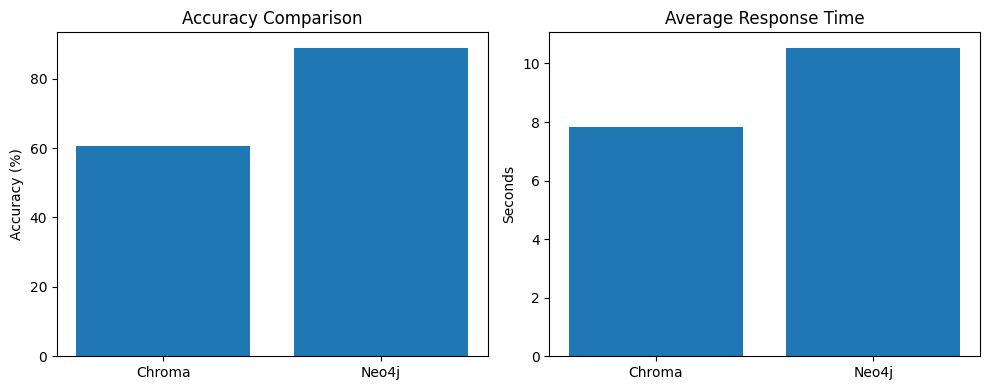

In [ ]:
metrics_plot = pd.DataFrame({
    "System": ["Chroma", "Neo4j"],
    "Accuracy": [chroma_accuracy, neo4j_accuracy],
    "Average Time": [avg_chroma_time, avg_neo4j_time]
})

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(metrics_plot["System"], metrics_plot["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.subplot(1, 2, 2)
plt.bar(metrics_plot["System"], metrics_plot["Average Time"])
plt.title("Average Response Time")
plt.ylabel("Seconds")

plt.tight_layout()
plt.show()
